# 01 — Data Exploration

Exploring the synthetic B2B SaaS dataset to understand the landscape before modeling.

**Questions we want to answer:**
1. What does the account distribution look like by segment, industry, and region?
2. What's the contact composition — seniority levels, job functions?
3. What's our deal funnel and win rate?
4. Which contact and account attributes correlate with winning deals?
5. What initial hypotheses can we form about lead scoring signals?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Load data
accounts = pd.read_csv("../data/accounts.csv")
contacts = pd.read_csv("../data/contacts.csv")
opportunities = pd.read_csv("../data/opportunities.csv")
contact_opp = pd.read_csv("../data/contact_opportunity.csv")

print(f"Accounts:     {len(accounts):,}")
print(f"Contacts:     {len(contacts):,}")
print(f"Opportunities: {len(opportunities):,}")
print(f"Contact roles: {len(contact_opp):,}")

Accounts:     100,000
Contacts:     717,820
Opportunities: 50,000
Contact roles: 122,677


## Account Distribution

How are accounts distributed across segments, industries, and regions?

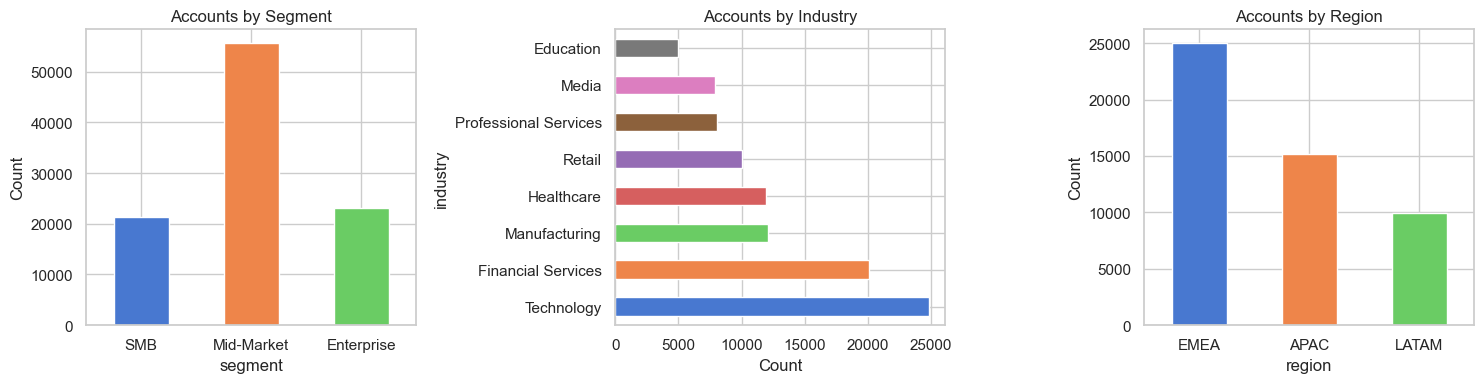

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Segment distribution
segment_order = ["SMB", "Mid-Market", "Enterprise"]
accounts["segment"].value_counts().reindex(segment_order).plot.bar(ax=axes[0], color=sns.color_palette("muted"))
axes[0].set_title("Accounts by Segment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Industry distribution
accounts["industry"].value_counts().plot.barh(ax=axes[1], color=sns.color_palette("muted"))
axes[1].set_title("Accounts by Industry")
axes[1].set_xlabel("Count")

# Region distribution
accounts["region"].value_counts().plot.bar(ax=axes[2], color=sns.color_palette("muted"))
axes[2].set_title("Accounts by Region")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

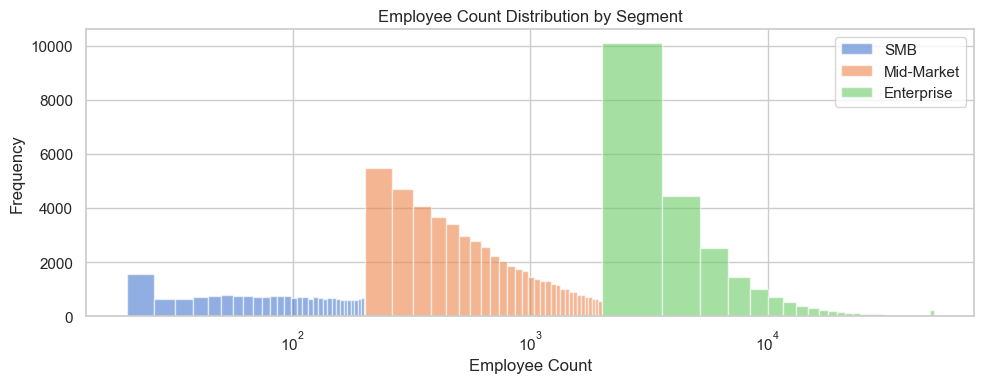

Account stats by segment:
            employee_count  annual_revenue  arr
segment                                        
SMB                  101.0      19108221.0  0.0
Mid-Market           634.0     127451635.5  0.0
Enterprise          4015.0     849091705.5  0.0


In [3]:
# Account size distribution by segment
fig, ax = plt.subplots(figsize=(10, 4))
for seg in segment_order:
    subset = accounts[accounts["segment"] == seg]
    ax.hist(subset["employee_count"], bins=30, alpha=0.6, label=seg)
ax.set_xlabel("Employee Count")
ax.set_ylabel("Frequency")
ax.set_title("Employee Count Distribution by Segment")
ax.legend()
ax.set_xscale("log")
plt.tight_layout()
plt.show()

# Summary stats
print("Account stats by segment:")
print(accounts.groupby("segment")[["employee_count", "annual_revenue", "arr"]].median()
      .reindex(segment_order).to_string())

## Contact Composition

Who are the people in our database? Distribution by seniority and job function.

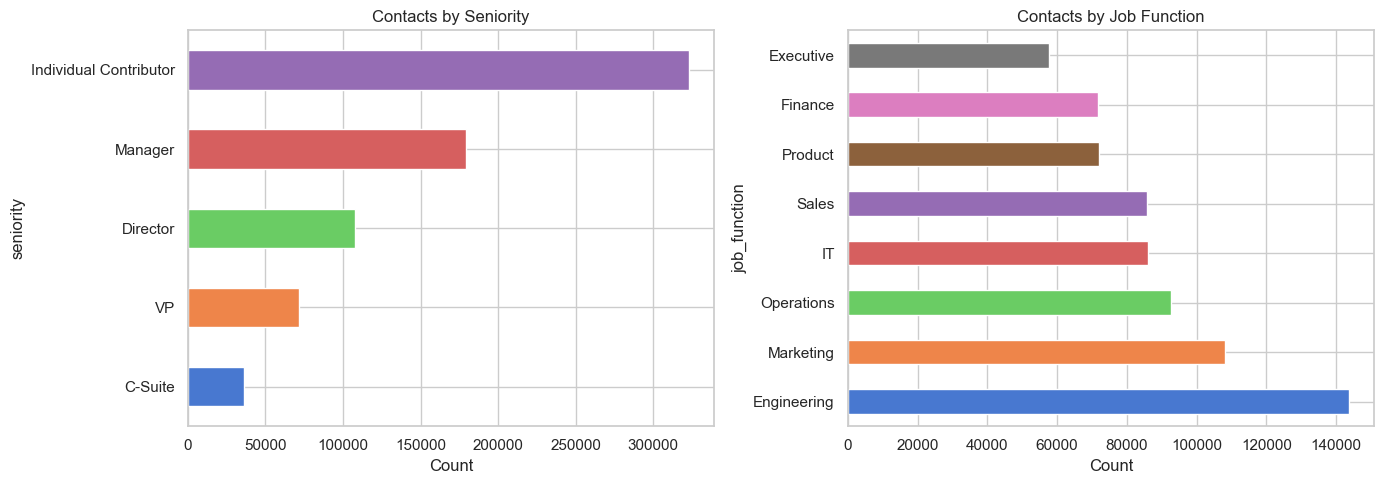

Contacts per account — Median: 7, Mean: 7.2, Min: 2, Max: 27


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seniority distribution
seniority_order = ["C-Suite", "VP", "Director", "Manager", "Individual Contributor"]
contacts["seniority"].value_counts().reindex(seniority_order).plot.barh(ax=axes[0], color=sns.color_palette("muted"))
axes[0].set_title("Contacts by Seniority")
axes[0].set_xlabel("Count")

# Job function distribution
contacts["job_function"].value_counts().plot.barh(ax=axes[1], color=sns.color_palette("muted"))
axes[1].set_title("Contacts by Job Function")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

# Contacts per account
contacts_per_acct = contacts.groupby("account_id").size()
print(f"Contacts per account — Median: {contacts_per_acct.median():.0f}, "
      f"Mean: {contacts_per_acct.mean():.1f}, "
      f"Min: {contacts_per_acct.min()}, Max: {contacts_per_acct.max()}")

## Deal Funnel & Win Rates

What does the opportunity pipeline look like? What's our overall win rate, and how does it vary?

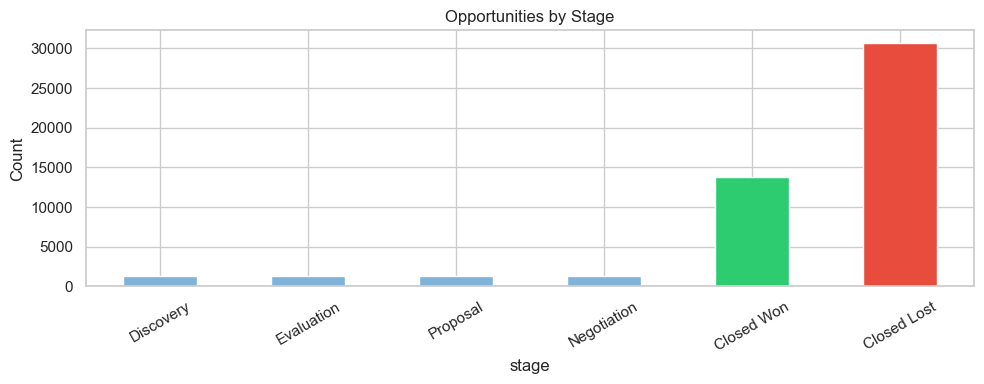

Total opportunities: 50000
Closed deals: 44545
Overall win rate (closed deals): 31.0%
Open deals still in pipeline: 5455


In [5]:
# Overall funnel
stage_order = ["Discovery", "Evaluation", "Proposal", "Negotiation", "Closed Won", "Closed Lost"]
stage_counts = opportunities["stage"].value_counts().reindex(stage_order).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#7fb3d8"] * 4 + ["#2ecc71", "#e74c3c"]
stage_counts.plot.bar(ax=ax, color=colors)
ax.set_title("Opportunities by Stage")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# Win rate
closed = opportunities[opportunities["stage"].isin(["Closed Won", "Closed Lost"])]
print(f"Total opportunities: {len(opportunities)}")
print(f"Closed deals: {len(closed)}")
print(f"Overall win rate (closed deals): {closed['is_won'].mean():.1%}")
print(f"Open deals still in pipeline: {len(opportunities) - len(closed)}")

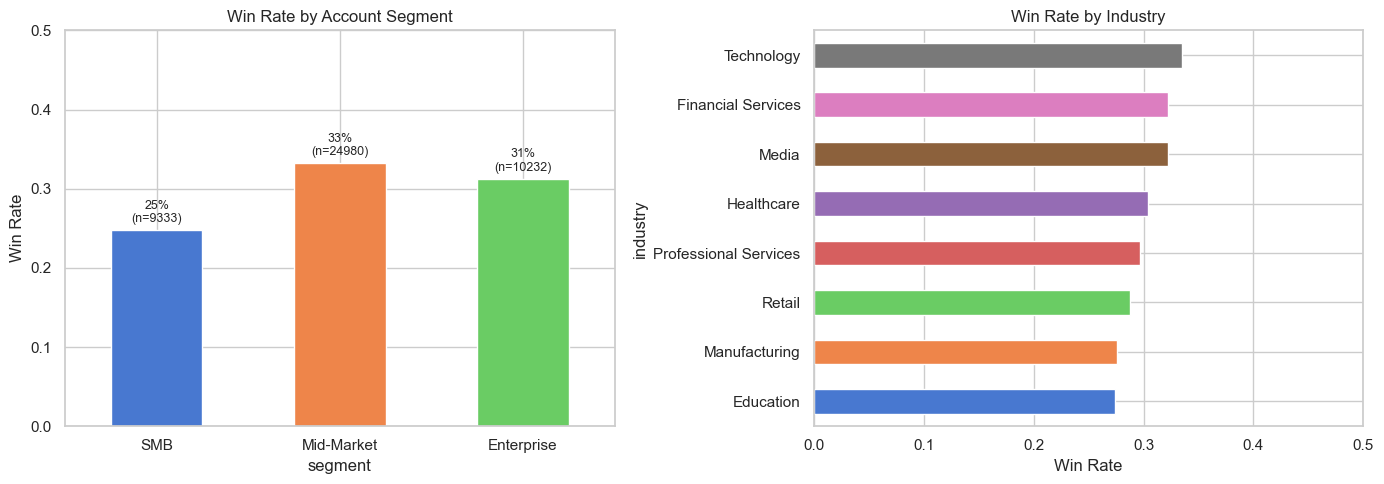

In [6]:
# Win rate by segment
opp_acct = opportunities.merge(accounts[["account_id", "segment", "industry"]], on="account_id")
closed_acct = opp_acct[opp_acct["stage"].isin(["Closed Won", "Closed Lost"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By segment
win_by_seg = closed_acct.groupby("segment")["is_won"].agg(["mean", "count"]).reindex(segment_order)
win_by_seg["mean"].plot.bar(ax=axes[0], color=sns.color_palette("muted"))
axes[0].set_title("Win Rate by Account Segment")
axes[0].set_ylabel("Win Rate")
axes[0].set_ylim(0, 0.5)
axes[0].tick_params(axis="x", rotation=0)
for i, (idx, row) in enumerate(win_by_seg.iterrows()):
    axes[0].text(i, row["mean"] + 0.01, f'{row["mean"]:.0%}\n(n={row["count"]:.0f})', ha="center", fontsize=9)

# By industry
win_by_ind = closed_acct.groupby("industry")["is_won"].agg(["mean", "count"]).sort_values("mean", ascending=True)
win_by_ind["mean"].plot.barh(ax=axes[1], color=sns.color_palette("muted"))
axes[1].set_title("Win Rate by Industry")
axes[1].set_xlabel("Win Rate")
axes[1].set_xlim(0, 0.5)

plt.tight_layout()
plt.show()

## Signal Hunting: What Predicts a Won Deal?

Let's look at the contact-level and account-level attributes that might predict deal outcomes. These will inform our feature engineering.

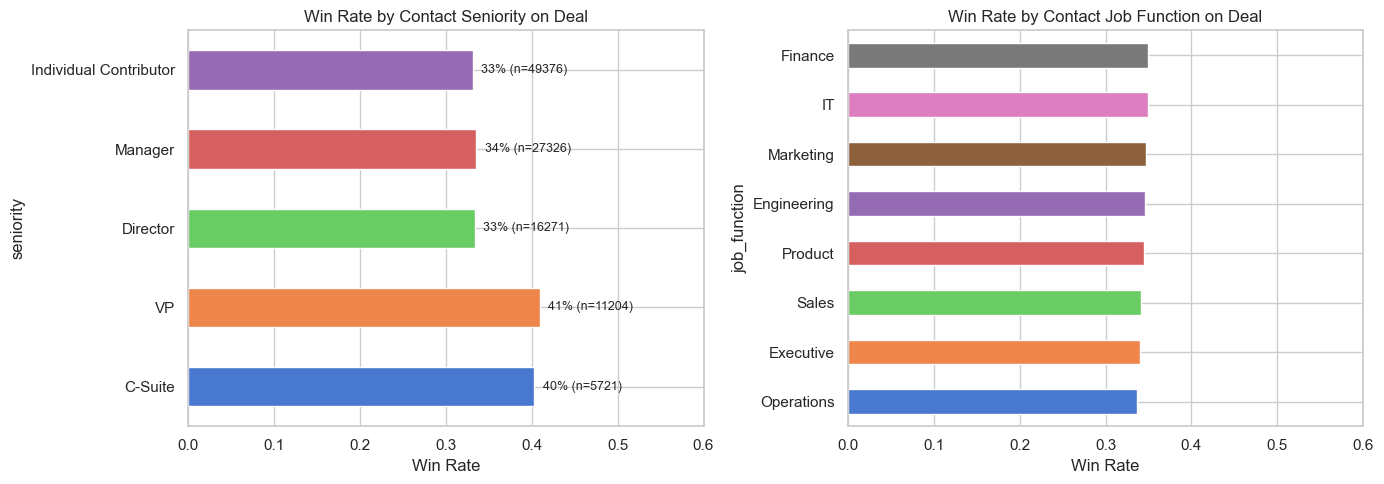

In [7]:
# Enrich contact_opp with contact details and deal outcome
deal_contacts = (
    contact_opp
    .merge(contacts[["contact_id", "seniority", "job_function"]], on="contact_id")
    .merge(opportunities[["opportunity_id", "is_won", "stage"]], on="opportunity_id")
)

# Only look at closed deals for signal analysis
closed_deals = deal_contacts[deal_contacts["stage"].isin(["Closed Won", "Closed Lost"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win rate by seniority of contacts on the deal
win_by_sen = closed_deals.groupby("seniority")["is_won"].agg(["mean", "count"]).reindex(seniority_order)
win_by_sen["mean"].plot.barh(ax=axes[0], color=sns.color_palette("muted"))
axes[0].set_title("Win Rate by Contact Seniority on Deal")
axes[0].set_xlabel("Win Rate")
axes[0].set_xlim(0, 0.6)
for i, (idx, row) in enumerate(win_by_sen.iterrows()):
    axes[0].text(row["mean"] + 0.01, i, f'{row["mean"]:.0%} (n={row["count"]:.0f})', va="center", fontsize=9)

# Win rate by job function of contacts on the deal
win_by_func = closed_deals.groupby("job_function")["is_won"].agg(["mean", "count"]).sort_values("mean")
win_by_func["mean"].plot.barh(ax=axes[1], color=sns.color_palette("muted"))
axes[1].set_title("Win Rate by Contact Job Function on Deal")
axes[1].set_xlabel("Win Rate")
axes[1].set_xlim(0, 0.6)

plt.tight_layout()
plt.show()

In [8]:
# Key signal: VP+ presence on the deal
opp_has_vp = (
    deal_contacts[deal_contacts["seniority"].isin(["C-Suite", "VP"])]
    .groupby("opportunity_id")["is_won"].first()
)
opp_no_vp = opportunities[
    ~opportunities["opportunity_id"].isin(opp_has_vp.index)
    & opportunities["stage"].isin(["Closed Won", "Closed Lost"])
]["is_won"]

print("=== VP+ Signal ===")
print(f"Win rate WITH VP+ on deal:    {opp_has_vp.mean():.1%}  (n={len(opp_has_vp)})")
print(f"Win rate WITHOUT VP+ on deal: {opp_no_vp.mean():.1%}  (n={len(opp_no_vp)})")
print(f"Lift: {opp_has_vp.mean() / opp_no_vp.mean():.1f}x")

=== VP+ Signal ===
Win rate WITH VP+ on deal:    36.7%  (n=15922)
Win rate WITHOUT VP+ on deal: 26.4%  (n=30087)
Lift: 1.4x


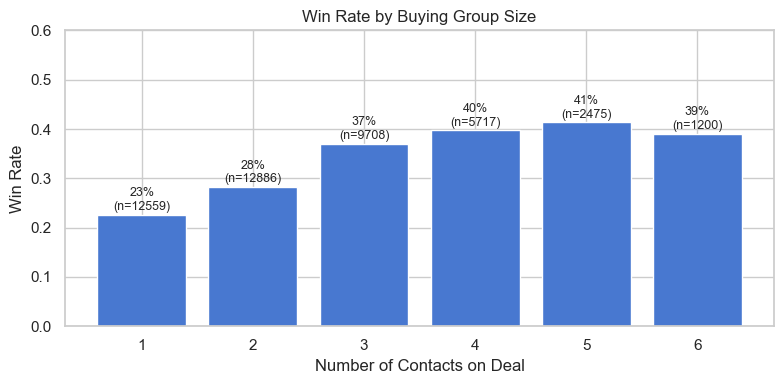


=== Buying Group Size Signal ===
Win rate with 1-2 contacts: 25.4%
Win rate with 3+ contacts:  38.5%
Lift: 1.5x


In [9]:
# Key signal: Number of contacts on the deal (buying group size)
contact_counts = contact_opp.groupby("opportunity_id").size().reset_index(name="n_contacts")
opp_with_counts = opportunities.merge(contact_counts, on="opportunity_id")
closed_with_counts = opp_with_counts[opp_with_counts["stage"].isin(["Closed Won", "Closed Lost"])]

fig, ax = plt.subplots(figsize=(8, 4))
win_by_count = closed_with_counts.groupby("n_contacts")["is_won"].agg(["mean", "count"])
bars = ax.bar(win_by_count.index, win_by_count["mean"], color=sns.color_palette("muted")[0])
ax.set_xlabel("Number of Contacts on Deal")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate by Buying Group Size")
ax.set_ylim(0, 0.6)

for bar, (idx, row) in zip(bars, win_by_count.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row["mean"]:.0%}\n(n={row["count"]:.0f})', ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Buying Group Size Signal ===")
small = closed_with_counts[closed_with_counts["n_contacts"] <= 2]["is_won"].mean()
large = closed_with_counts[closed_with_counts["n_contacts"] >= 3]["is_won"].mean()
print(f"Win rate with 1-2 contacts: {small:.1%}")
print(f"Win rate with 3+ contacts:  {large:.1%}")
print(f"Lift: {large / small:.1f}x")

In [10]:
# Key signal: Technical + Business function mix on the deal
opp_functions = (
    deal_contacts
    .groupby("opportunity_id")
    .agg(
        functions=("job_function", set),
        is_won=("is_won", "first"),
        stage=("stage", "first"),
    )
)
opp_functions = opp_functions[opp_functions["stage"].isin(["Closed Won", "Closed Lost"])]

technical = {"Engineering", "IT", "Product"}
business = {"Marketing", "Sales", "Finance", "Executive"}

opp_functions["has_technical"] = opp_functions["functions"].apply(lambda f: bool(f & technical))
opp_functions["has_business"] = opp_functions["functions"].apply(lambda f: bool(f & business))
opp_functions["has_both"] = opp_functions["has_technical"] & opp_functions["has_business"]

print("=== Technical + Business Function Mix ===")
both = opp_functions[opp_functions["has_both"]]["is_won"].mean()
not_both = opp_functions[~opp_functions["has_both"]]["is_won"].mean()
print(f"Win rate with BOTH technical + business contacts: {both:.1%}  (n={opp_functions['has_both'].sum()})")
print(f"Win rate WITHOUT both:                            {not_both:.1%}  (n={(~opp_functions['has_both']).sum()})")
print(f"Lift: {both / not_both:.1f}x")

=== Technical + Business Function Mix ===
Win rate with BOTH technical + business contacts: 38.0%  (n=19012)
Win rate WITHOUT both:                            25.8%  (n=25533)
Lift: 1.5x


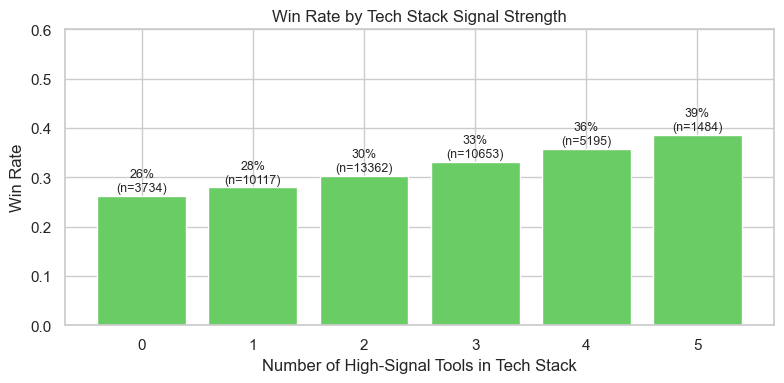

In [11]:
# Key signal: Tech stack (complementary tools)
high_signal_tools = {"Jira", "Salesforce", "Slack", "Snowflake", "AWS"}

opp_tech = opportunities.merge(accounts[["account_id", "tech_stack"]], on="account_id")
closed_tech = opp_tech[opp_tech["stage"].isin(["Closed Won", "Closed Lost"])].copy()
closed_tech["high_signal_count"] = closed_tech["tech_stack"].apply(
    lambda ts: len(set(t.strip() for t in ts.split(",")) & high_signal_tools)
)

fig, ax = plt.subplots(figsize=(8, 4))
win_by_tech = closed_tech.groupby("high_signal_count")["is_won"].agg(["mean", "count"])
bars = ax.bar(win_by_tech.index, win_by_tech["mean"], color=sns.color_palette("muted")[2])
ax.set_xlabel("Number of High-Signal Tools in Tech Stack")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate by Tech Stack Signal Strength")
ax.set_ylim(0, 0.6)

for bar, (idx, row) in zip(bars, win_by_tech.iterrows()):
    if row["count"] >= 5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{row["mean"]:.0%}\n(n={row["count"]:.0f})', ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Deal Size Distribution

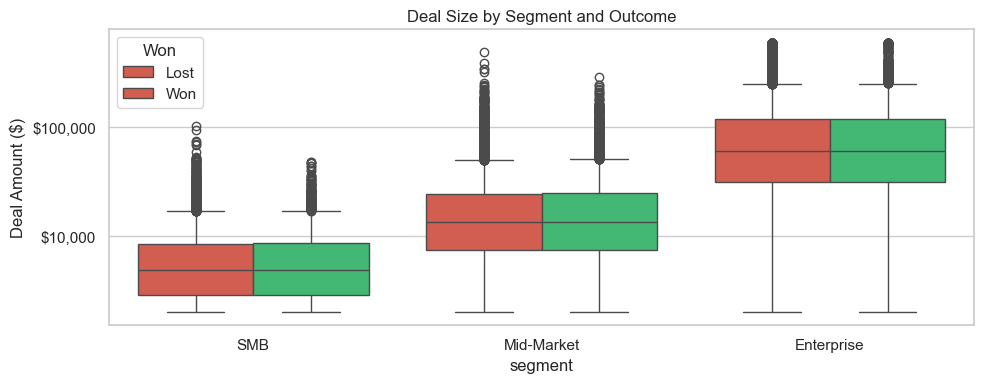

Median deal size by segment:
segment
SMB            $4,883
Mid-Market    $13,358
Enterprise    $60,937


In [12]:
# Deal size by segment and outcome
fig, ax = plt.subplots(figsize=(10, 4))
closed_opp_acct = closed_acct.copy()
sns.boxplot(data=closed_opp_acct, x="segment", y="amount", hue="is_won",
            order=segment_order, ax=ax, palette={True: "#2ecc71", False: "#e74c3c"})
ax.set_yscale("log")
ax.set_title("Deal Size by Segment and Outcome")
ax.set_ylabel("Deal Amount ($)")
ax.legend(title="Won", labels=["Lost", "Won"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print("Median deal size by segment:")
print(closed_opp_acct.groupby("segment")["amount"].median().reindex(segment_order)
      .apply(lambda x: f"${x:,.0f}").to_string())

## Summary & Hypotheses

**What we've found so far:**

1. **Seniority matters.** Deals with VP+ contacts win at significantly higher rates than those with only mid-level or IC contacts.

2. **Buying group size matters.** Deals with 3+ contacts convert at higher rates than 1-2 contact deals. This is the core buying group signal.

3. **Function diversity matters.** Having both technical (Engineering, IT, Product) AND business (Marketing, Sales, Finance, Executive) contacts on a deal increases win rates.

4. **Tech stack signals exist.** Accounts with complementary tools (Jira, Salesforce, Slack, Snowflake, AWS) in their stack show higher conversion.

5. **Mid-Market is the sweet spot.** Highest win rate by segment, with meaningful deal sizes.

**Next steps:** In the feature engineering notebook, we'll encode these signals as model features and validate their predictive power more rigorously.